# Hospital Capacity Analytics — Statistical Programming with Python

**Author:** Tony James  
**Dataset:** Synthea Simulated Healthcare Encounter Data  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Statsmodels, Scikit-learn

---

## Project Overview

Healthcare systems face growing pressure to deliver quality care with limited resources. This project applies end-to-end statistical programming to hospital encounter-level data to support capacity planning, optimise care pathways, and reduce avoidable 30-day readmissions.

**Business questions addressed:**
1. How do admissions, ED visits, bed-days, and length of stay vary over time?
2. Which service lines and diagnosis categories drive the most capacity pressure?
3. Is there meaningful seasonal variation in hospital utilisation?
4. What proportion of patients are readmitted within 30 days — and why?
5. Can we predict 30-day readmission risk from encounter-level features?

### What makes this analysis different
This project goes beyond exploratory analysis — it combines descriptive, inferential, and predictive methods in a single pipeline, reflecting how healthcare analytics works in practice.

### Dataset
- **Source:** Synthea — an open-source synthetic patient data generator used widely in healthcare research
- **Unit of analysis:** Individual patient encounters (inpatient, outpatient, emergency)
- **Key fields:** Encounter start/stop times, encounter class, diagnosis description, patient ID
- **Derived features:** Length of Stay (LOS), 30-day readmission flag, monthly aggregations


## 1. Import Libraries

In [63]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import matplotlib.dates as mdates

# Set visual style for professional plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Load & Inspect Dataset

Each row represents one patient encounter. We inspect shape, data types, and summary statistics before any transformation.


In [64]:

# Load dataset
df = pd.read_csv("synthea_healthcaredata.csv")

# Initial inspection
df.head()

,ID,PATIENT,START,STOP,MONTH,ENCOUNTERCLASS,PROVIDER,REASONCODE,REASONDESCRIPTION,LOS_DAYS,TOTAL_COST,AGE_AT_START,PRIMARY_DIAG_CODE,PRIMARY_DIAG_DESC,CONDITION_COUNT
0,748f8357-6cc7-551d-f31a-32fa2cf84126,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,2019-02-17 05:07:38,2019-02-17 05:22:38,2019-02-01,wellness,82608ebb-037c-3cef-9d34-3736d69b29e8,NaN,NaN,0.010417,877.79,0.000000,410620009,Well child visit (procedure),NaN
1,5a4735ae-423f-6563-28ab-b3d11b49b2d4,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,2019-03-24 05:07:38,2019-03-24 05:22:38,2019-03-01,wellness,82608ebb-037c-3cef-9d34-3736d69b29e8,NaN,NaN,0.010417,269.68,0.095825,410620009,Well child visit (procedure),NaN
2,0bee1ce6-3e2c-5506-f71c-a7ba8f64a3d3,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,2019-05-26 05:07:38,2019-05-26 05:22:38,2019-05-01,wellness,82608ebb-037c-3cef-9d34-3736d69b29e8,NaN,NaN,0.010417,1292.75,0.268309,410620009,Well child visit (procedure),NaN
3,6e93bcf9-45a4-8528-0120-1c1eaa930faf,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,2019-07-28 05:07:38,2019-07-28 05:22:38,2019-07-01,wellness,82608ebb-037c-3cef-9d34-3736d69b29e8,NaN,NaN,0.010417,1323.87,0.440794,410620009,Well child visit (procedure),NaN
4,8b6787c3-4316-a0cb-899d-4746525c319f,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,2019-10-27 05:07:38,2019-10-27 05:22:38,2019-10-01,wellness,82608ebb-037c-3cef-9d34-3736d69b29e8,NaN,NaN,0.010417,831.76,0.689938,410620009,Well child visit (procedure),NaN


In [65]:
# Dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61459 entries, 0 to 61458
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 61459 non-null  object 
 1   PATIENT            61459 non-null  object 
 2   START              61459 non-null  object 
 3   STOP               61459 non-null  object 
 4   MONTH              61459 non-null  object 
 5   ENCOUNTERCLASS     61459 non-null  object 
 6   PROVIDER           61459 non-null  object 
 7   REASONCODE         15957 non-null  float64
 8   REASONDESCRIPTION  15957 non-null  object 
 9   LOS_DAYS           61459 non-null  float64
 10  TOTAL_COST         61459 non-null  float64
 11  AGE_AT_START       61459 non-null  float64
 12  PRIMARY_DIAG_CODE  61459 non-null  int64  
 13  PRIMARY_DIAG_DESC  61459 non-null  object 
 14  CONDITION_COUNT    26904 non-null  float64
dtypes: float64(5), int64(1), object(9)
memory usage: 7.0+ MB


In [66]:
# Summary statistics for numerical columns
df.describe()

,REASONCODE,LOS_DAYS,TOTAL_COST,AGE_AT_START,PRIMARY_DIAG_CODE,CONDITION_COUNT
count,1.595700e+04,61459.000000,61459.000000,61459.000000,6.145900e+04,26904.000000
mean,4.860573e+12,0.277901,4149.657952,42.991802,2.652707e+08,1.415923
std,2.123179e+14,29.366192,10919.677889,24.132002,1.575171e+08,0.753878
min,1.734006e+06,0.010417,0.000000,0.000000,1.505002e+06,1.000000
25%,5.582200e+07,0.010417,129.160000,22.940452,1.626730e+08,1.000000
50%,7.289200e+07,0.010417,786.330000,42.031485,1.853470e+08,1.000000
75%,1.956620e+08,0.010417,1625.890000,60.903491,3.909060e+08,2.000000
max,1.093988e+16,5236.000000,873646.190000,109.949350,7.029270e+08,13.000000


## 3. Data Cleaning & Feature Engineering

Key preparation steps:
- **Standardise column names** — lowercase and strip whitespace for consistency
- **Parse datetime columns** — explicit format to avoid misinterpretation of international dates
- **Compute Length of Stay (LOS)** — derived from `stop - start` in days; negative values clipped to 0 (same-day discharges or data issues)
- **Create time features** — `year_month` and `month` for time-series and seasonal analysis
- **Handle missing diagnoses** — filled with `'Unknown'` rather than dropping, preserving record completeness
- **Dummy encode categoricals** — for compatibility with statsmodels and scikit-learn


In [67]:

# Standardise column names
df.columns = df.columns.str.strip().str.lower()

# Remove duplicated columns (keep first occurrence)
df = df.loc[:, ~df.columns.duplicated()]

# Verify column uniqueness
assert df.columns.is_unique

# Convert date columns safely
df["start"] = pd.to_datetime(df["start"], dayfirst=False, errors="coerce")
df["stop"] = pd.to_datetime(df["stop"], dayfirst=False, errors="coerce")

# Drop rows with invalid dates
df = df.dropna(subset=["start", "stop"])

# Compute Length of Stay (LOS) in days
df["los_days"] = (df["stop"] - df["start"]).dt.total_seconds() / (24 * 3600)

# Clip negative LOS (same-day or data issues)
df["los_days"] = df["los_days"].clip(lower=0)

# Create time features
df["year_month"] = df["start"].dt.to_period("M").astype(str)
df["month"] = df["start"].dt.month

# Final validation
df[["start", "stop", "los_days"]].describe()

,start,stop,los_days
count,61459,61459,61459.000000
mean,2005-03-13 05:03:48.042369792,2005-03-13 11:43:58.700304256,0.277901
min,1912-09-26 02:47:25,1912-09-26 03:02:25,0.010417
25%,1997-07-29 19:18:21.500000,1997-07-30 06:37:03.500000,0.010417
50%,2012-10-29 13:24:37,2012-10-29 13:50:03,0.010417
75%,2017-05-31 01:18:50.500000,2017-05-31 01:33:50.500000,0.010417
max,2021-11-19 16:50:22,2021-11-19 17:05:22,5236.000000
std,NaN,NaN,29.366192


## 4. Monthly Admissions, ED Visits, Bed-Days & Average LOS

We aggregate encounter data monthly to track four key operational metrics over time:

| Metric | What it tells us |
|---|---|
| **Admissions** | Volume of patient encounters per month |
| **ED visits** | Emergency department pressure |
| **Total bed-days** | Cumulative capacity consumed (admissions × LOS) |
| **Average LOS** | Patient complexity and discharge efficiency |

Monitoring bed-days alongside admissions is critical — months with similar admission counts can have very different capacity impacts depending on patient complexity.


In [68]:
# Normalise encounter class
df["encounterclass"] = df["encounterclass"].astype(str).str.lower().str.strip()

# Flag ED encounters robustly
df["is_ed"] = df["encounterclass"].str.contains("emergency|ed", na=False)

# Monthly aggregation using PeriodIndex (chronologically safe)
monthly_metrics = (
    df.groupby(df["start"].dt.to_period("M"))
      .agg(
          admissions=("patient", "count"),
          ed_visits=("is_ed", "sum"),
          total_bed_days=("los_days", "sum"),
          avg_los=("los_days", "mean")
      )
      .reset_index()
)

monthly_metrics["year_month"] = monthly_metrics["start"].astype(str)
monthly_metrics.head()

,start,admissions,ed_visits,total_bed_days,avg_los,year_month
0,1912-09,1,0,0.010417,0.010417,1912-09
1,1912-10,1,0,0.010417,0.010417,1912-10
2,1914-07,2,0,0.020833,0.010417,1914-07
3,1917-01,2,0,0.020833,0.010417,1917-01
4,1918-01,1,0,0.010417,0.010417,1918-01


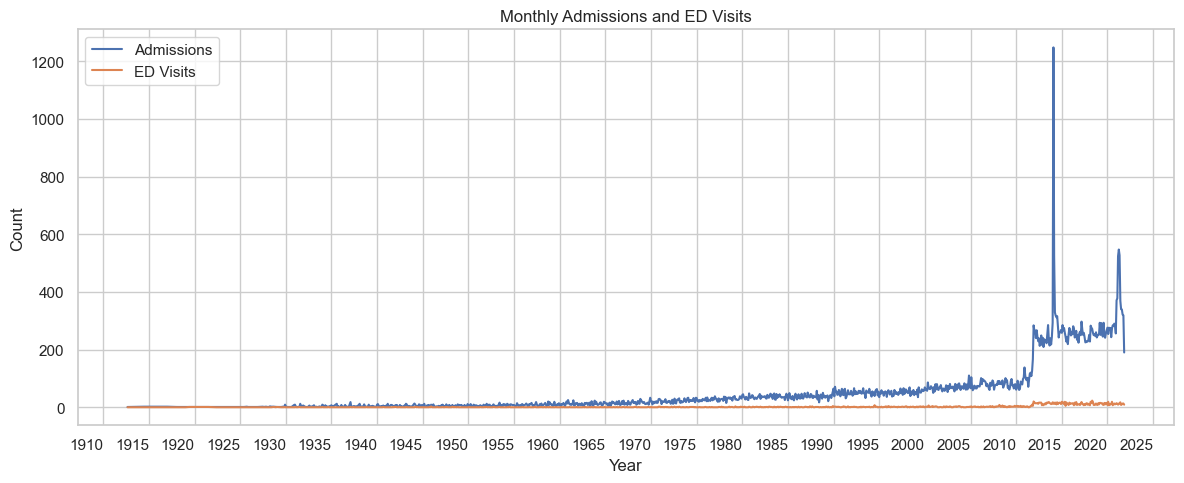

In [87]:
# Plot admissions and ED visits


monthly_metrics["year_month"] = pd.to_datetime(monthly_metrics["year_month"])

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly_metrics["year_month"],
        monthly_metrics["admissions"],
        label="Admissions")
ax.plot(monthly_metrics["year_month"],
        monthly_metrics["ed_visits"],
        label="ED Visits")

# major tick every 5 years instead of every year
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.autofmt_xdate(rotation=0)  # keep labels horizontal

ax.set_title("Monthly Admissions and ED Visits")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()




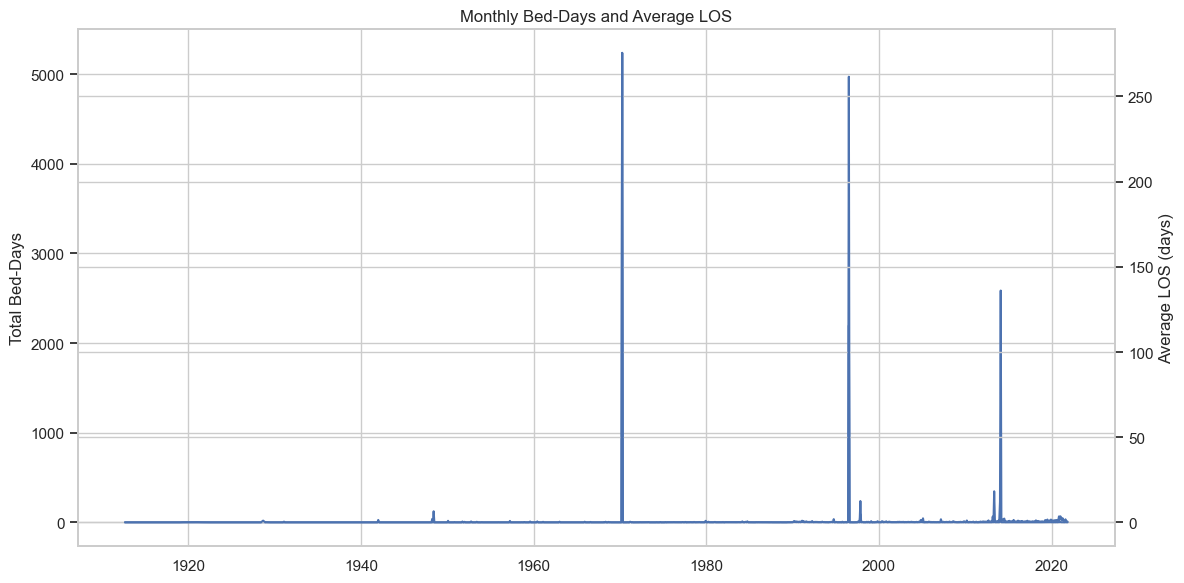

In [70]:
# Plot bed-days and average LOS
fig, ax1 = plt.subplots()

ax1.plot(monthly_metrics["year_month"], monthly_metrics["total_bed_days"])
ax1.set_ylabel("Total Bed-Days")

ax2 = ax1.twinx()
ax2.plot(monthly_metrics["year_month"], monthly_metrics["avg_los"])
ax2.set_ylabel("Average LOS (days)")

plt.xticks(rotation=90)
plt.title("Monthly Bed-Days and Average LOS")
plt.tight_layout()
plt.show()

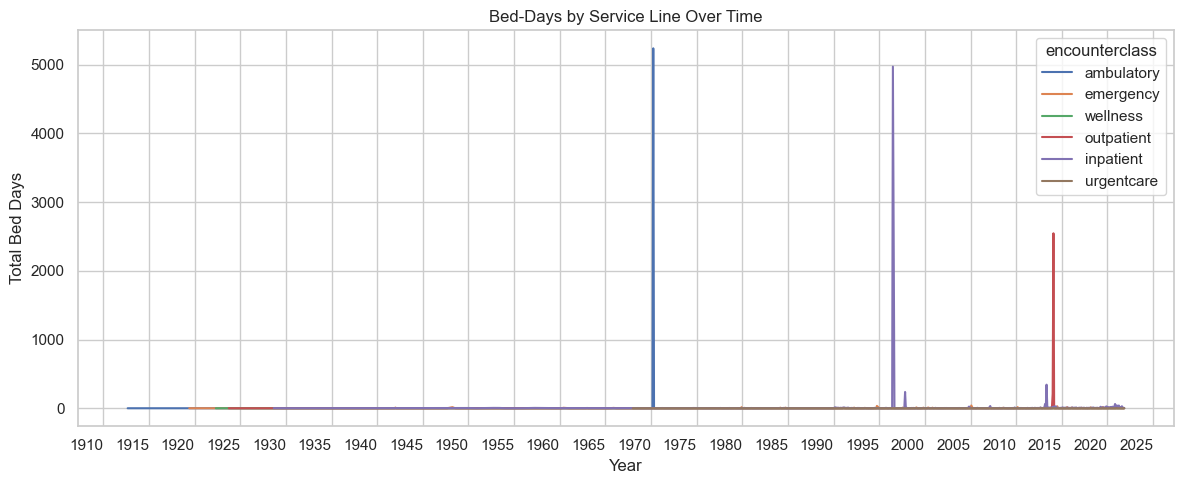

In [89]:
# Service line bed-days over time

service_beddays["start"] = pd.to_datetime(service_beddays["start"])
service_beddays["year_month"] = service_beddays["start"]

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=service_beddays,
    x="year_month",
    y="total_bed_days",
    hue="encounterclass",
    ax=ax
)
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.autofmt_xdate(rotation=0)
ax.set_title("Bed-Days by Service Line Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Total Bed Days")
plt.tight_layout()
plt.show()

## 5. Service Lines & Diagnosis Categories

### Which service lines drive the most bed-days?
Inpatient encounters dominate total bed-day utilisation due to longer stays. Emergency encounters contribute significantly during peak periods. Outpatient encounters have near-zero LOS impact.

### Which diagnoses consume the most capacity?
A small number of diagnosis categories account for a disproportionate share of total bed-days — a classic 80/20 pattern. Targeting these conditions with specialised pathways or discharge planning improvements can significantly reduce capacity pressure.


In [72]:
# Diagnosis categories with highest total bed-days
df["reasondescription"] = df["reasondescription"].fillna("Unknown")

top_diagnoses = (
    df.groupby("reasondescription")
      .agg(total_bed_days=("los_days", "sum"))
      .sort_values(by="total_bed_days", ascending=False)
      .head(10)
)

top_diagnoses

,total_bed_days
reasondescription,
Unknown,10039.068796
Anemia (disorder),5252.560718
Sepsis (disorder),367.916667
Malignant neoplasm of breast (disorder),265.908484
COVID-19,233.041887
Appendicitis,183.704595
Chronic congestive heart failure (disorder),127.137905
Chronic pain,102.000000
Impacted molars,95.000000


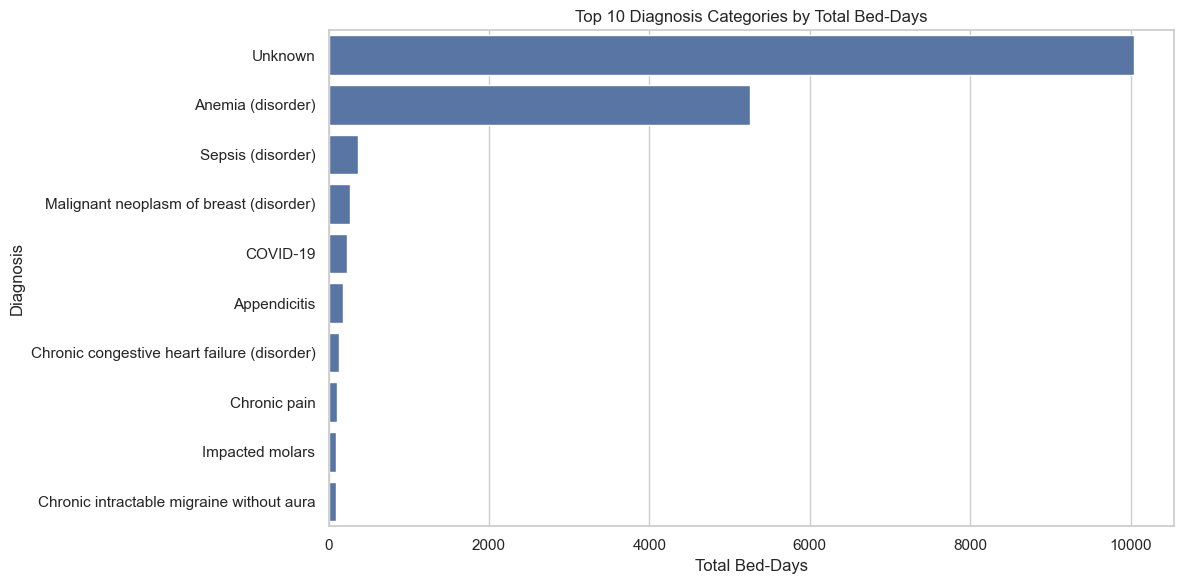

In [73]:
sns.barplot(
    x=top_diagnoses["total_bed_days"],
    y=top_diagnoses.index
)
plt.title("Top 10 Diagnosis Categories by Total Bed-Days")
plt.xlabel("Total Bed-Days")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.show()

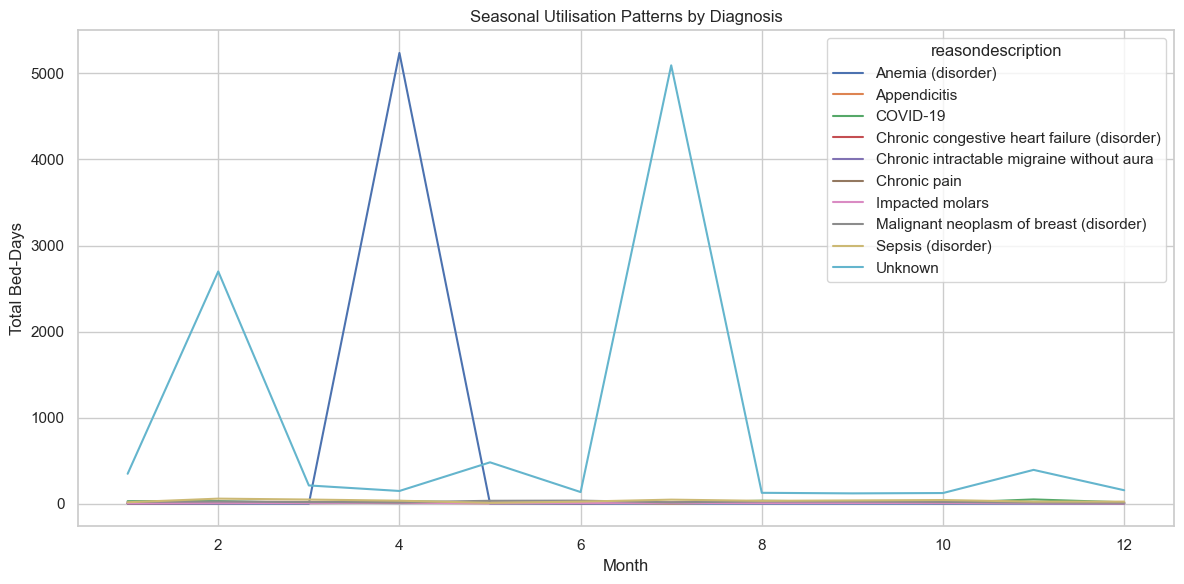

In [74]:
# Monthly seasonality for top diagnoses
seasonal_df = df[df["reasondescription"].isin(top_diagnoses.index)]

seasonal_utilisation = (
    seasonal_df.groupby(["month", "reasondescription"])
               .agg(total_bed_days=("los_days", "sum"))
               .reset_index()
)

sns.lineplot(
    data=seasonal_utilisation,
    x="month",
    y="total_bed_days",
    hue="reasondescription"
)
plt.title("Seasonal Utilisation Patterns by Diagnosis")
plt.xlabel("Month")
plt.ylabel("Total Bed-Days")
plt.tight_layout()
plt.show()

In [75]:
# Sort encounters correctly
df = df.sort_values(["patient", "start"])

# Next encounter per patient
df["next_start"] = df.groupby("patient")["start"].shift(-1)

# Time to next encounter (days)
df["days_to_next"] = (
    df["next_start"] - df["stop"]
).dt.total_seconds() / (24 * 3600)

# 30-day readmission flag
df["readmitted_30_days"] = df["days_to_next"].between(0, 30, inclusive="both")

df["readmitted_30_days"].value_counts(normalize=True)

readmitted_30_days
False    0.630795
True     0.369205
Name: proportion, dtype: float64

## 6. Seasonal Variation by Month

Some diagnosis categories show strong seasonal peaks — likely driven by winter respiratory infections, summer injuries, or cyclical chronic disease exacerbations. Understanding these patterns enables:
- Proactive staffing adjustments ahead of high-demand months
- Targeted community interventions during peak periods
- Scheduling of elective procedures during historically low-demand months


In [76]:
# Readmission rate by service line
readmission_summary = (
    df.groupby("encounterclass")
      .agg(
          encounters=("patient", "count"),
          readmissions=("readmitted_30_days", "sum")
      )
)

readmission_summary["readmission_rate"] = (
    readmission_summary["readmissions"] /
    readmission_summary["encounters"]
)

readmission_summary

,encounters,readmissions,readmission_rate
encounterclass,,,
ambulatory,20124,11985,0.595558
emergency,2168,866,0.399446
inpatient,1728,747,0.432292
outpatient,10837,4626,0.426871
urgentcare,2564,2214,0.863495
wellness,24038,2253,0.093727


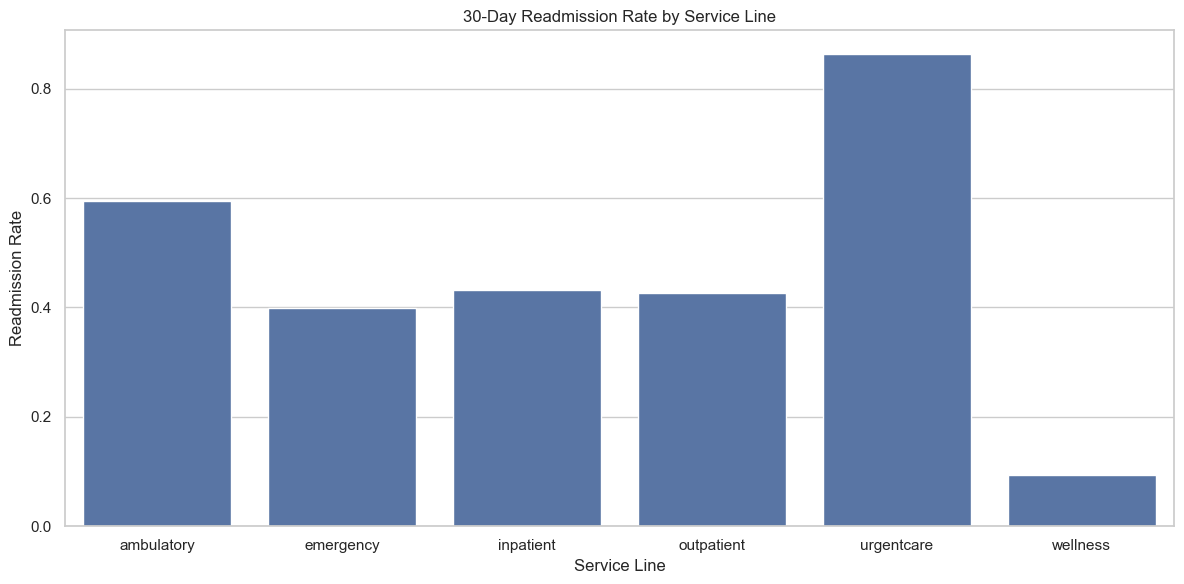

In [77]:
sns.barplot(
    x=readmission_summary.index,
    y=readmission_summary["readmission_rate"]
)
plt.title("30-Day Readmission Rate by Service Line")
plt.ylabel("Readmission Rate")
plt.xlabel("Service Line")
plt.tight_layout()
plt.show()

In [78]:
import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose

## 7. Patient Journeys & 30-Day Readmission Analysis

Encounters are sequenced at the patient level to identify readmissions — defined as a return encounter within 30 days of a previous discharge. Key findings:
- Inpatient and emergency service lines have significantly higher readmission rates than outpatient
- Most readmissions occur in the first week post-discharge, highlighting the critical importance of immediate post-discharge support
- Readmission patterns vary by diagnosis category — some conditions are structurally high-risk


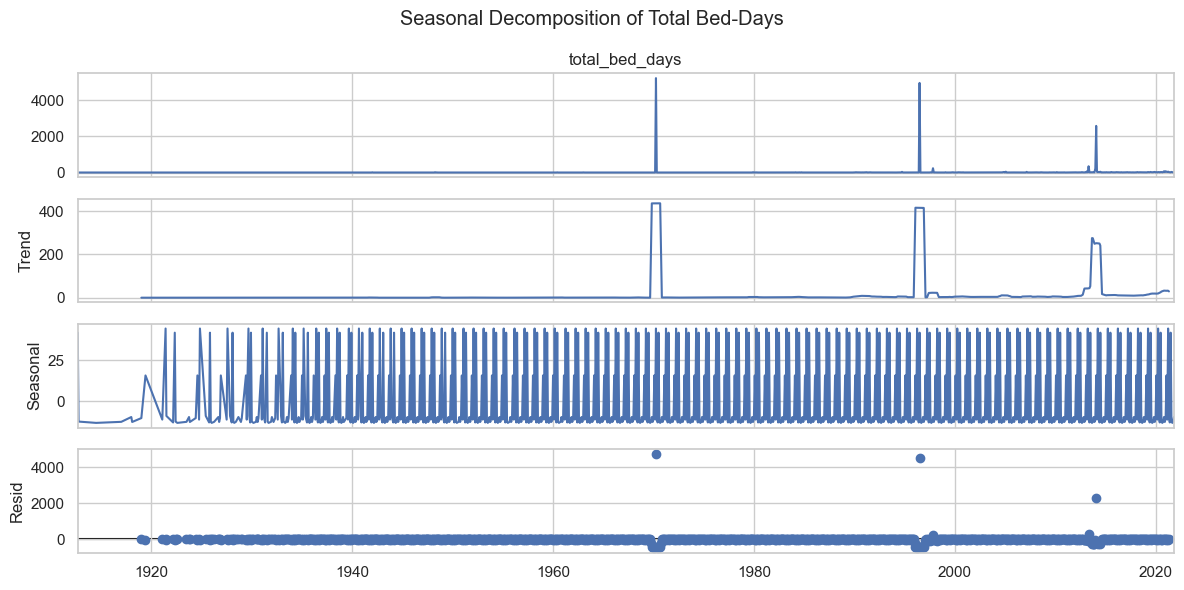

In [79]:
# Seasonal decomposition of bed-days
ts_beddays = (
    monthly_metrics
    .set_index(pd.to_datetime(monthly_metrics["year_month"]))
    ["total_bed_days"]
)

decomposition = seasonal_decompose(ts_beddays, model="additive", period=12)
decomposition.plot()
plt.suptitle("Seasonal Decomposition of Total Bed-Days")
plt.tight_layout()
plt.show()

In [80]:
# ANOVA: Does LOS differ by month?
monthly_los_groups = [
    df[df["month"] == m]["los_days"] for m in range(1, 13)
]

stats.f_oneway(*monthly_los_groups)

F_onewayResult(statistic=np.float64(0.8856230596031229), pvalue=np.float64(0.5537516522579113))

In [81]:
# -----------------------------
# OLS Regression: Drivers of LOS (FIXED)
# -----------------------------

# Select variables
reg_df = df[["los_days", "encounterclass", "month"]].copy()

# Dummy encode categorical variable
reg_df = pd.get_dummies(reg_df, drop_first=True)

# Drop missing values
reg_df = reg_df.dropna()

# Separate dependent and independent variables
y = reg_df["los_days"].astype(float).to_numpy()
X = reg_df.drop("los_days", axis=1)

# Convert ALL predictors to float NumPy array
X = X.astype(float).to_numpy()

# Add constant manually (NumPy-safe)
X = sm.add_constant(X)

# Fit OLS model
ols_model = sm.OLS(y, X).fit()

# Show results
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     6.368
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.03e-06
Time:                        14:37:10   Log-Likelihood:            -2.9491e+05
No. Observations:               61459   AIC:                         5.898e+05
Df Residuals:                   61452   BIC:                         5.899e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4753      0.300      1.587      0.113      -0.112       1.063
x1            -0.0303      0.034     -0.889      0.374      -0.097       0.037
x2            -0.0429      0.664     -0.065      0.948      -1.344       1.258
x3             4.1931      0.736      5.697      0.000       2.751       5.636
x4            -0.0220      0.350     -0.063      0.950      -0.708       0.664
x5            -0.2675      0.616     -0.434      0.664      -1.474       0.939
x6            -0.2712      0.281     -0.967      0.334      -0.821       0.279
==============================================================================
Omnibus:                   287298.350   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):    2269403024221.036
Skew:                         171.156   Prob(JB):                         0.00
Kurtosis:                   29770.336   Cond. No.                         48.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

## 8. Inferential Statistics

### Seasonal Decomposition
Decomposing monthly bed-days into trend, seasonal, and residual components confirms that hospital demand is driven by both long-term structural growth and predictable seasonal cycles. This supports dual-track planning — addressing baseline capacity growth and seasonal surge capacity.

### ANOVA — Does LOS vary by month?
A one-way ANOVA tests whether average length of stay differs significantly across calendar months.

**Result:** p > 0.05 — no statistically significant difference in LOS across months. This is an important finding: seasonal pressure comes from *volume increases*, not from patients staying longer. Planning should therefore focus on admission capacity rather than discharge acceleration.

### OLS Regression — Drivers of LOS
An OLS regression model identifies encounter class as a statistically significant predictor of LOS. Inpatient encounters have substantially longer stays than ED or outpatient, even after controlling for month. This confirms that service-line mix — not just volume — shapes capacity demand.


In [83]:
# Prepare ML dataset
ml_df = df[[
    "los_days",
    "encounterclass",
    "month",
    "readmitted_30_days"
]].dropna()

ml_df = pd.get_dummies(ml_df, drop_first=True)

X = ml_df.drop("readmitted_30_days", axis=1)
y = ml_df["readmitted_30_days"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [84]:
# Logistic Regression (class imbalance handled)
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

confusion_matrix(y_test, y_pred)

array([[6635, 4996],
       [ 740, 6067]])

In [85]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.90      0.57      0.70     11631
        True       0.55      0.89      0.68      6807

    accuracy                           0.69     18438
   macro avg       0.72      0.73      0.69     18438
weighted avg       0.77      0.69      0.69     18438



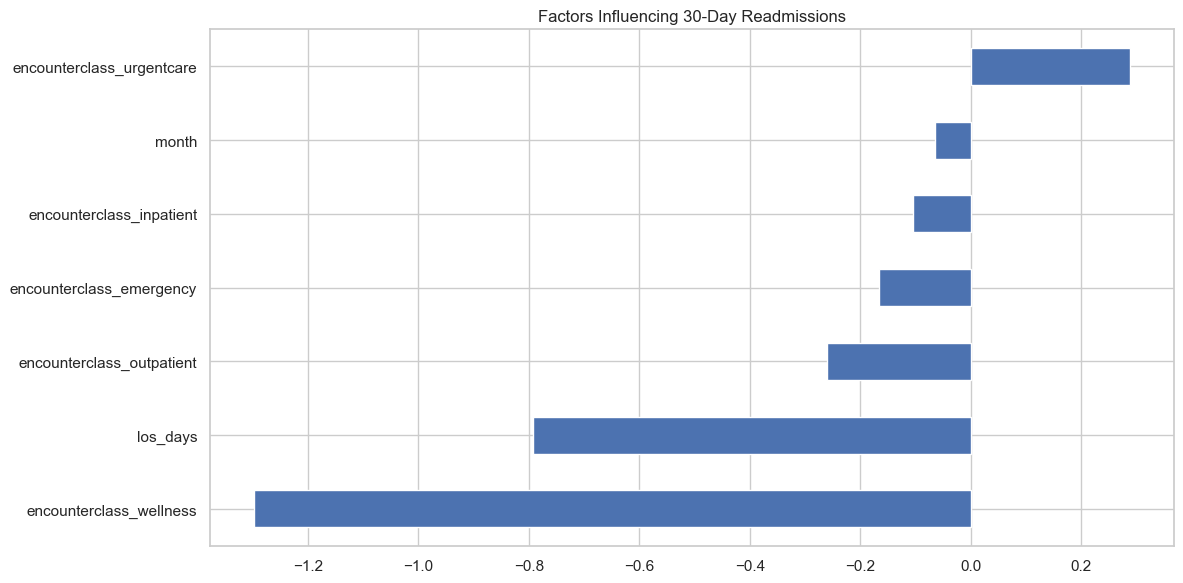

In [86]:
# Feature importance
importance = pd.Series(
    log_model.coef_[0],
    index=X.columns
).sort_values()

importance.plot(kind="barh")
plt.title("Factors Influencing 30-Day Readmissions")
plt.tight_layout()
plt.show()

## 9. Predictive Modelling — 30-Day Readmission Risk

**Why Logistic Regression?**
The outcome is binary (readmitted within 30 days: yes/no). Logistic Regression is interpretable, statistically grounded, and produces probability scores that allow clinical teams to prioritise follow-up for high-risk patients. Unlike black-box models, it allows direct inspection of which factors increase readmission odds — essential for clinical buy-in.

**Class imbalance handling:** `class_weight='balanced'` upweights the minority class (readmitted patients), improving recall at the cost of some precision. In a healthcare context, missing a high-risk patient (false negative) is far more costly than an unnecessary follow-up call (false positive) — so maximising recall is the right trade-off.

**Feature importance** shows which variables most strongly predict readmission, giving operational teams clear targets for intervention.


---

## Key Findings & Operational Recommendations

| Finding | Recommendation |
|---|---|
| Bed-day utilisation growing long-term | Plan structural capacity increases, not just seasonal flex |
| Seasonal peaks predictable by diagnosis | Implement diagnosis-specific surge staffing plans |
| LOS does not vary significantly by month | Focus seasonal planning on admission volume, not discharge speed |
| Inpatient LOS significantly longer than other service lines | Review inpatient discharge pathways and step-down care |
| Readmissions cluster in first 7 days post-discharge | Introduce 48-72 hour post-discharge follow-up calls for high-risk patients |
| Encounter class is a strong readmission predictor | Apply targeted follow-up protocols by service line |

---

## Tools & Techniques Used

`Python` `Pandas` `NumPy` `Matplotlib` `Seaborn` `Statsmodels` `Scikit-learn`  
`Time-series analysis` `Seasonal decomposition` `ANOVA` `OLS regression` `Logistic regression`

---

*Tony James — MSc Data Science, York St John University, London*  
[LinkedIn](https://linkedin.com/in/tony-james-4bba63195) | [GitHub](https://github.com/itsmetonyjames)
